<h2>Decision Tree Algorithm</h2>

A Decision Tree is a supervised machine learning algorithms used for :

- Classification
- Regression

In [3]:
import pandas as pd

f1 = ["sunny","sunny","overcast","rain","rain","rain","overcast","sunny","sunny","rain","sunny","overcast","overcast","rain"]
op = ["no","no","yes","yes","no","yes","yes","yes","yes","yes","yes","yes","yes","no"]
df = pd.DataFrame({
    "F1":f1,
    "O/p":op
})

In [4]:
df

,F1,O/p
0,sunny,no
1,sunny,no
2,overcast,yes
3,rain,yes
4,rain,no
5,rain,yes
6,overcast,yes
7,sunny,yes
8,sunny,yes
9,rain,yes


<h3>To check the purity</h3>

- Entroy
- Gini Index

<h3>To Pick feature for splitting</h3>

- Information Gain

## 1. Entropy

Entropy measures the impurity or randomness in a dataset.

\[
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
\]

Where:

- \(S\) = Dataset
- \(c\) = Number of classes
- \(p_i\) = Probability of class \(i\)

### Example

\[
Entropy(S) = -(0.6 \log_2(0.6) + 0.4 \log_2(0.4))
\]

---

## 2. Gini Impurity

Gini Impurity measures the probability of incorrectly classifying a randomly chosen element.

\[
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
\]

Where:

- \(S\) = Dataset
- \(c\) = Number of classes
- \(p_i\) = Probability of class \(i\)

### Example

\[
Gini(S) = 1 - (0.6^2 + 0.4^2)
\]

---

## 3. Information Gain

Information Gain measures the reduction in entropy after splitting a dataset.

\[
IG(S, A) = Entropy(S) - \sum_{v \in Values(A)}
\frac{|S_v|}{|S|} Entropy(S_v)
\]

Where:

- \(S\) = Original dataset
- \(A\) = Feature used for splitting
- \(v\) = Possible values of feature \(A\)
- \(S_v\) = Subset of \(S\) where feature \(A = v\)
- \(|S_v|\) = Number of samples in subset \(S_v\)
- \(|S|\) = Total number of samples

<h3>Information Gain</h3>

It determine the feature to split

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [6]:
data = {
    'Age':[25,30,45,35,22,40],
    'Salary':[30000,50000,80000,65000,20000,90000],
    'Buy':[0,1,1,1,0,1]
}

df = pd.DataFrame(data)

In [7]:
df

,Age,Salary,Buy
0,25,30000,0
1,30,50000,1
2,45,80000,1
3,35,65000,1
4,22,20000,0
5,40,90000,1


In [8]:
X = df[['Age','Salary']]
y = df['Buy']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(accuracy_score(y_test,y_pred))

1.0


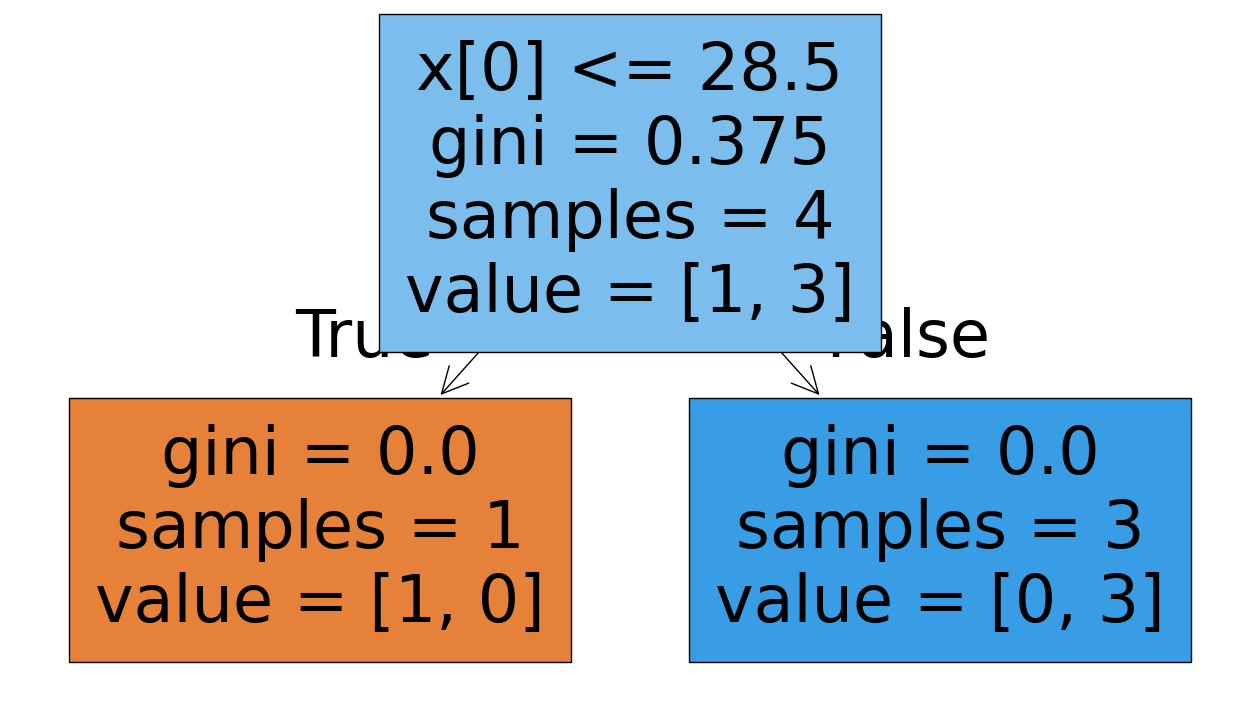

In [15]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))

tree.plot_tree(model,filled=True)

plt.show()

In [17]:
from sklearn.datasets import load_iris

In [18]:
X = load_iris().data

y = load_iris().target

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
model = DecisionTreeClassifier(max_depth=2)

model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [40]:
y_pred = model.predict(X_test)

In [41]:
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [38]:
len(X_test)

30

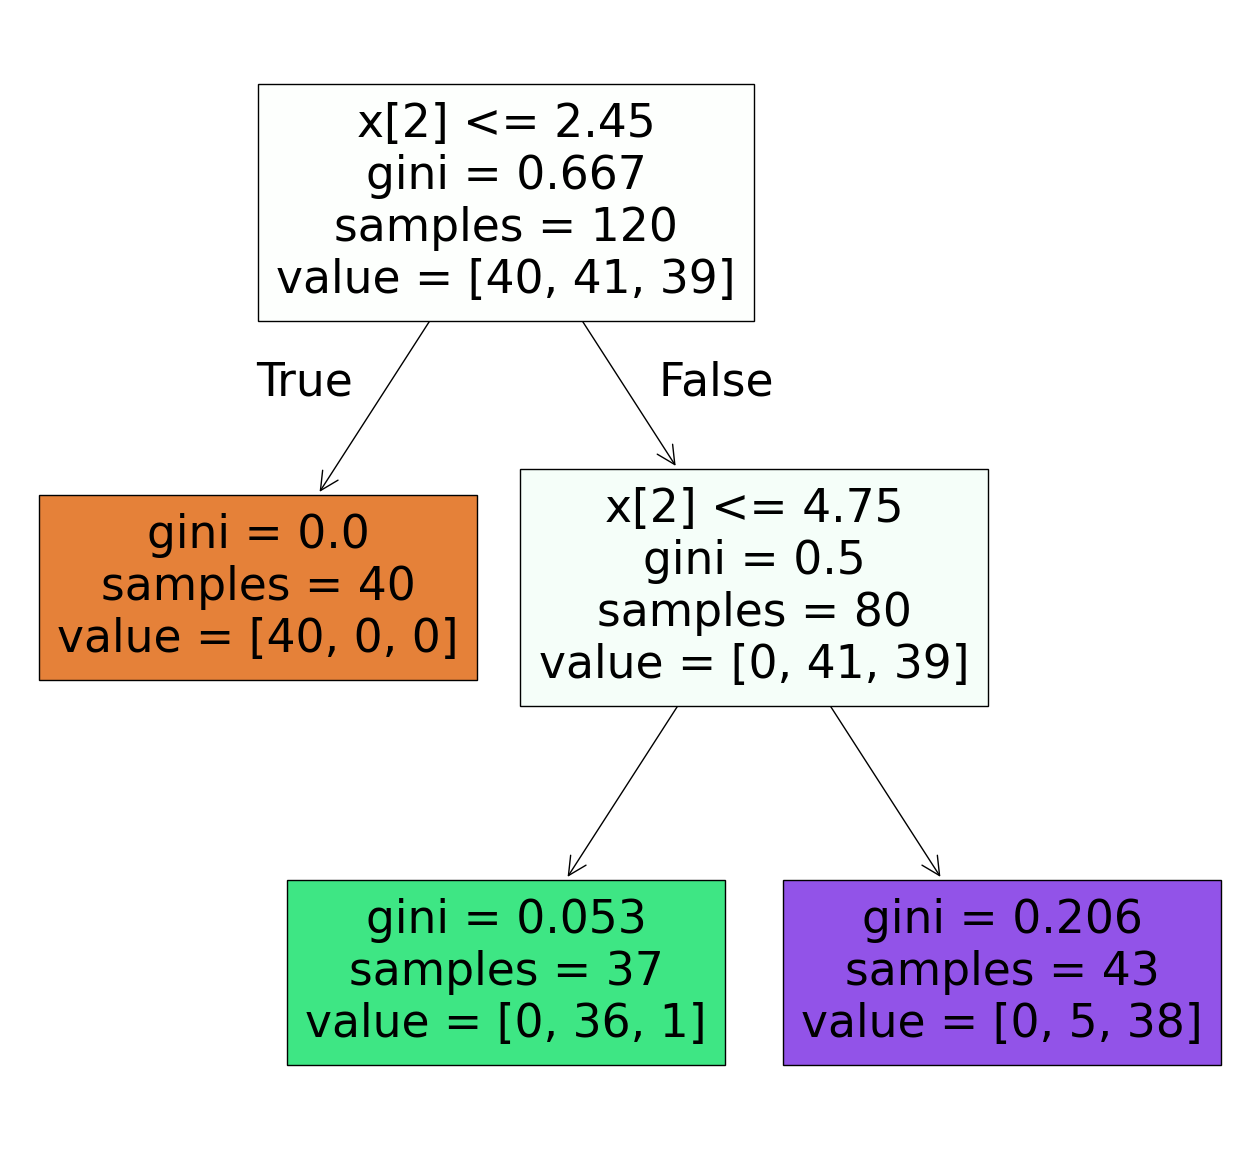

In [42]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,15))

tree.plot_tree(model,filled=True)

plt.show()

To control the model to be overfitted we apply pruning techniques:


Post Pruning

Pre pruning